In [2]:
import os, shutil, random

TRAIN_RATIO = 0.85
images_src = "dataset_1/images"
labels_src = "dataset_1/labels"

images = [f for f in os.listdir(images_src) if f.endswith(".png")]
random.seed(42)
random.shuffle(images)

for folder in ["data/images/train", "data/images/val", "data/labels/train", "data/labels/val"]:
    os.makedirs(folder, exist_ok=True)

for i, img in enumerate(images):
    label = img.replace(".png", ".txt")
    dest = "train" if i < int(len(images) * TRAIN_RATIO) else "val"

    shutil.copy(os.path.join(images_src, img), os.path.join("data/images", dest, img))
    label_path = os.path.join(labels_src, label)
    if os.path.exists(label_path):
        shutil.copy(label_path, os.path.join("data/labels", dest, label))

print(f"Done — train: {int(len(images) * TRAIN_RATIO)}, val: {len(images) - int(len(images) * TRAIN_RATIO)}")

Done — train: 363, val: 65


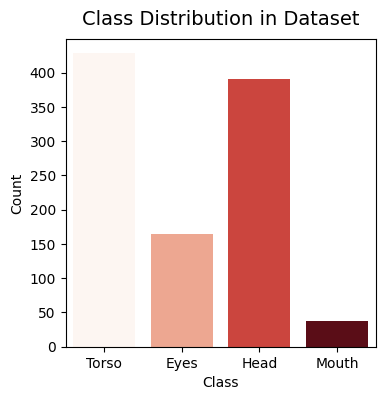

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

labels_path = "dataset_1/labels"

classes = range(0, 4)
class_counts = {c: 0 for c in classes}
for file in os.listdir(labels_path):
    if file.endswith(".txt"):
        with open(os.path.join(labels_path, file), "r") as f:
            for line in f:
                cls = int(line.split()[0])
                if cls in class_counts:
                    class_counts[cls] += 1

# Hardcoded class labels for better visualization
labels = ["Torso", "Eyes", "Head", "Mouth"]

# Convert class_counts to a DataFrame for better visualization
df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
plt.figure(figsize=(4, 4))
sns.barplot(x="Class", y="Count", data=df, hue="Class", palette="Reds", legend=False)
plt.title("Class Distribution in Dataset", fontsize=14, pad=10)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes, labels)
plt.show()

In [27]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [4]:
from ultralytics import YOLO
from clearml import Task

task = Task.init(project_name="Main", task_name="YOLO Training")

model = YOLO("yolo11n.pt")
model.train(
    data="dataset_1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="runs",
    name="fatigue-v1",
    device=0
)

task.close()

ClearML Task: overwriting (reusing) task id=6aa6067547144d409d3985651d30ebe6
ClearML results page: https://app.clear.ml/projects/bab4f98ba6d147688fafe06e98131cbe/experiments/6aa6067547144d409d3985651d30ebe6/output/log
Ultralytics 8.4.25  Python-3.13.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask

KeyboardInterrupt: 

In [29]:
import cv2
from ultralytics import YOLO

model = YOLO("best.pt")
cap = cv2.VideoCapture(0)  # 0 = default webcam
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

while True:
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()  # draws boxes + labels on frame

    cv2.imshow("FatigueSense - Live Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):  # press Q to quit
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 1 Head, 1 Torso, 1 Mouth, 2 Eyess, 72.2ms
Speed: 6.5ms preprocess, 72.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Mouth, 2 Eyess, 14.1ms
Speed: 2.0ms preprocess, 14.1ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Mouth, 2 Eyess, 12.2ms
Speed: 1.7ms preprocess, 12.2ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Mouth, 2 Eyess, 15.1ms
Speed: 3.4ms preprocess, 15.1ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Torso, 1 Mouth, 2 Eyess, 18.0ms
Speed: 2.7ms preprocess, 18.0ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Torso, 1 Mouth, 2 Eyess, 17.6ms
Speed: 2.3ms preprocess, 17.6ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Head, 1 Torso, 1 Mouth, 2 Eyess, 15.1ms
Speed: 2.1ms preprocess, 15.1ms inference, 2.5ms postprocess per im